In [286]:
import pandas as	pd
import numpy as np
import	matplotlib.pyplot as plt
import	seaborn as sns

**Load cleaned_data.csv from Part 1. Define:**

In [287]:
df=pd.read_csv("cleaned_housing_data.csv")

In [288]:
df.shape

(250000, 23)

In [289]:
df.drop(columns=['ID'], inplace=True)

In [290]:
df.drop(columns=['Price_per_SqFt','Year_Built'], inplace=True)

Feature matrix X: all columns except the target.
Regression label y_reg: one continuous numeric column (e.g., price, income).

In [291]:
X=df.drop(columns=['Price_in_Lakhs'])


In [292]:
X.head(2)

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,Maharashtra,Pune,Locality_490,Independent House,3,2364,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction


In [293]:
df["Availability_Status"].unique()

array(['Ready_to_Move', 'Under_Construction'], dtype=object)

1.State
city
locality
property_type
furnished
Amenities
Facing	
Public_Transport_Accessibility,,Owner_Parking_SpaceType,Availability_Status, orinal encoding 

Classification label y_clf: a binary column derived by binarizing y_reg at its median (y_clf = (y_reg > y_reg.median()).astype(int)) or another natural binary column in the dataset. State both label definitions clearly in the README.

In [294]:
y_clf = (y_reg > y_reg.median()).astype(int)

In [295]:
print(y_clf.value_counts())

Price_in_Lakhs
1    50000
0    50000
Name: count, dtype: int64


**Encode categorical columns: For each categorical column in X:**

**Ordinal encoding**

In [296]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [297]:
Lab=LabelEncoder()

In [298]:
X["Public_Transport_Accessibility"]=Lab.fit_transform(X["Public_Transport_Accessibility"])
X["Parking_Space"]=Lab.fit_transform(X["Parking_Space"])
X["Owner_Type"]=Lab.fit_transform(X["Owner_Type"])
X["Availability_Status"]=Lab.fit_transform(X["Availability_Status"])
X["Security"]=Lab.fit_transform(X["Security"])

**ONEhot encoding**

In [299]:
X_encoded = pd.get_dummies(
    X[['State','City','Locality','Property_Type',"Furnished_Status","Facing","Amenities"]],dtype='int',sparse=True,
    drop_first=True
)

In [300]:
X_final=pd.DataFrame(X_encoded)

In [301]:
X.drop(columns=['State','City','Locality','Property_Type',"Furnished_Status","Facing","Amenities"], inplace=True)

In [302]:
X.columns.tolist()

['BHK',
 'Size_in_SqFt',
 'Floor_No',
 'Total_Floors',
 'Age_of_Property',
 'Nearby_Schools',
 'Nearby_Hospitals',
 'Public_Transport_Accessibility',
 'Parking_Space',
 'Security',
 'Owner_Type',
 'Availability_Status']

In [303]:
X_final=pd.concat([X.reset_index(drop=True), X_final.reset_index(drop=True)], axis=1)

In [304]:
X_final.shape

(250000, 902)

In [305]:
X_final=X_final.iloc[:100000]
y_reg=df['Price_in_Lakhs'].iloc[:100000]

In [306]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_reg, test_size=0.2, random_state=42)


In [307]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80000, 902), (20000, 902), (80000,), (20000,))

In [308]:
from sklearn.preprocessing	import StandardScaler
scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform both train and test using the fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


**Regression model — Linear Regression:**

Train a LinearRegression model from sklearn.linear_model on the scaled training features and y_reg_train.
Predict on X_test_scaled to get y_pred_reg.
Compute and report: MSE using mean_squared_error(y_reg_test, y_pred_reg) and R² using r2_score(y_reg_test, y_pred_reg).
Print the model's coefficients alongside the corresponding feature names. Identify the three features with the largest absolute coefficient values. In the README, interpret what a large positive coefficient means (as one unit increase in the scaled feature is associated with how many units increase in the predicted value) and what a large negative coefficient means.
Apply Ridge Regression (Ridge(alpha=1.0)) using the same split and scaling. Compare its MSE and R² against plain Linear Regression in a two-row comparison table in the README. Explain in one paragraph why Ridge might produce a different coefficient profile than OLS Linear Regression and what the alpha parameter controls.

In [309]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [310]:
LR.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [311]:
y_pred = LR.predict(X_test_scaled)

In [312]:
from sklearn.metrics import mean_squared_error, r2_score


print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 20043.983848453925
R^2 Score: -0.008746940397383884


In [313]:
# Build DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": LR.coef_
})

# Add absolute values for comparison
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# Sort by absolute value
coef_df_sorted = coef_df.sort_values(by="AbsCoefficient", ascending=False)

# Largest absolute coefficient
largest_abs = coef_df_sorted.iloc[0]
print("Largest absolute coefficient:")
print(largest_abs)

# Largest negative coefficient (most negative raw value)
largest_neg = coef_df.loc[coef_df["Coefficient"].idxmin()]
print("\nLargest negative coefficient:")
print(largest_neg)

Largest absolute coefficient:
Feature           Amenities_Playground, Pool, Garden
Coefficient                                 1.695821
AbsCoefficient                              1.695821
Name: 827, dtype: object

Largest negative coefficient:
Feature           Locality_Locality_251
Coefficient                   -1.295453
AbsCoefficient                 1.295453
Name: 240, dtype: object


In [314]:
importance=pd.DataFrame({
				"Feature": X_train.columns,		
     "coefficient": LR.coef_})
importance.sort_values(by="coefficient", ascending=False,key=abs)

,Feature,coefficient
827,"Amenities_Playground, Pool, Garden",1.695821
218,Locality_Locality_231,1.572040
399,Locality_Locality_395,1.550679
570,Locality_Locality_99,1.429670
128,Locality_Locality_150,1.393536
...,...,...
780,"Amenities_Playground, Clubhouse, Gym, Garden",-0.004616
421,Locality_Locality_414,0.003817
76,Locality_Locality_103,-0.003743
147,Locality_Locality_168,-0.002107


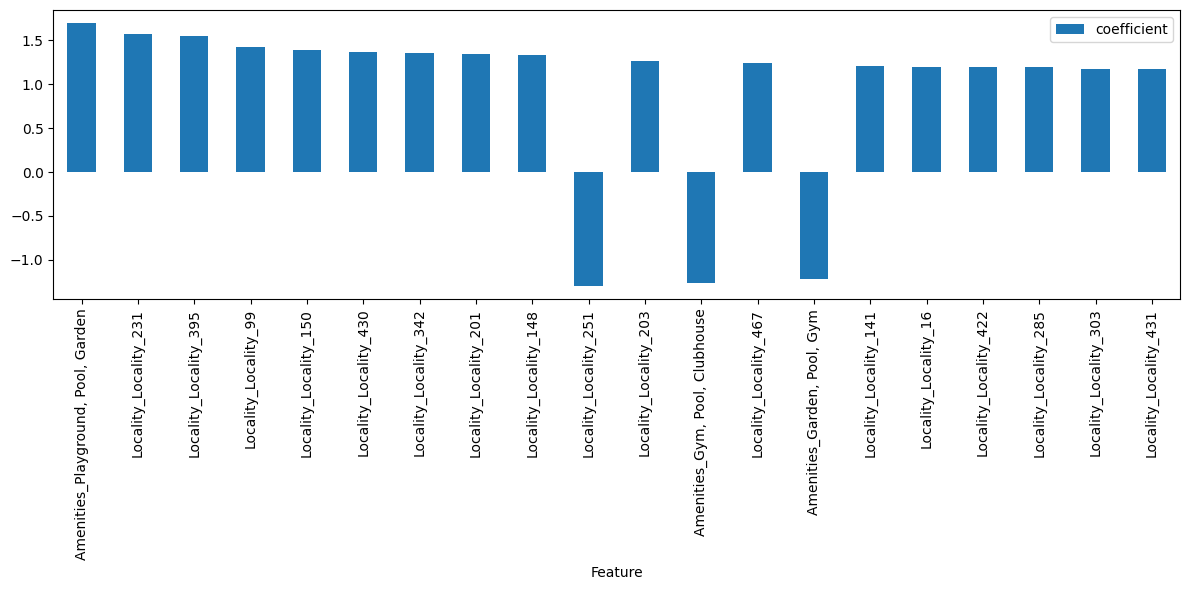

In [315]:
import	matplotlib.pyplot as plt
top20=importance.sort_values(by="coefficient", ascending=False,key=abs).head(20)
top20.plot(
  x='Feature',
		y='coefficient',
  kind='bar',
  figsize=(12, 6)
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Plain Linear Regression


mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

# Ridge Regression (alpha=1.0)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print comparison
print("Linear Regression - MSE:", mse_lr, "R²:", r2_lr)
print("Ridge Regression   - MSE:", mse_ridge, "R²:", r2_ridge)


Linear Regression - MSE: 20043.983848453925 R²: -0.008746940397383884
Ridge Regression   - MSE: 20043.977127769012 R²: -0.008746602167698736


In [317]:
"================================================task 3======================================================"

'================================================task 3======================================================'

In [318]:
from sklearn.tree	import DecisionTreeRegressor
dt1_regressor = DecisionTreeRegressor(random_state=42)


In [319]:
dt2_regressor = DecisionTreeRegressor(max_depth=5,min_samples_split=20,random_state=42) 

In [320]:
dt2_regressor.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [321]:
y_pred_dt = dt_regressor.predict(X_test_scaled)

In [322]:
from	sklearn.metrics import mean_squared_error, r2_score
print("Decision Tree Regressor - MSE:", mean_squared_error(y_test, y_pred_dt), "R²:", r2_score(y_test, y_pred_dt))
	

Decision Tree Regressor - MSE: 39936.439156784996 R²: -1.0098679541133513


d1_regression :
Decision Tree Regressor - MSE: 39936.439156784996 R²: -1.0098679541133513

In [326]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [327]:
rf = RandomForestRegressor()